# FinSight — Forecast Exploration

Purpose: pull real transaction data from Supabase, bucket it per category to see what monthly (or weekly/daily) granularity actually looks like, and use that to inform `forecaster.py`'s design — bucket size, `insufficient_data` threshold, and forecast horizon — before writing any Prophet code.

This notebook does not write anything back to Supabase. Read-only exploration.

## Setup

Reads `SUPABASE_URL` / `SUPABASE_KEY` from `backend/.env` — same credentials your FastAPI app already uses. Adjust `ENV_PATH` below if this notebook isn't sitting next to your `backend/` folder.

In [23]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from supabase import create_client

ENV_PATH = Path("../backend/.env")  # adjust if needed
load_dotenv(ENV_PATH)

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_KEY = os.environ["SUPABASE_KEY"]
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

## Pull transactions

Set `USER_ID` to your own test user's id (find it in Supabase Auth, or via a `/auth/login` call). Pulling everything for one user, matching how `/forecast` will actually be scoped per-request.

In [24]:
USER_ID = "328c7f2e-9d3d-46c2-a9cf-4c95267c4d01"

result = (
    supabase.table("transactions")
    .select("*")
    .eq("user_id", USER_ID)
    .execute()
)

df = pd.DataFrame(result.data)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
print(f"{len(df)} transactions, date range {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

1000 transactions, date range 2025-01-02 to 2026-07-21


,id,user_id,batch_id,date,description,amount,category,account_type,is_anomaly,anomaly_score,created_at,account_id
0,537a9397-ca49-4d09-8706-a4e9f39eadc8,328c7f2e-9d3d-46c2-a9cf-4c95267c4d01,643cda67-1906-4b42-b0b3-d3b357ab085e,2025-01-02,ONLINE BANKING TRANSFER - 4061,650.00,Transfer,chequing,False,None,2026-07-24T04:53:36.226378+00:00,01c1d4da-f7cd-4615-8a43-4e9568862530
758,c28dd30a-9c03-4135-81e1-722d40df428b,328c7f2e-9d3d-46c2-a9cf-4c95267c4d01,4eb625dd-613d-4b4b-9a3f-cd8e7bf8215c,2025-01-02,ONLINE BANKING TRANSFER - 4061,650.00,Transfer,chequing,False,None,2026-07-24T04:58:12.627204+00:00,01c1d4da-f7cd-4615-8a43-4e9568862530
759,86e6d4ab-45f2-4004-8876-922cc9d79e45,328c7f2e-9d3d-46c2-a9cf-4c95267c4d01,4eb625dd-613d-4b4b-9a3f-cd8e7bf8215c,2025-01-03,ONLINE BANKING TRANSFER - 0473,-52.72,Transfer,chequing,False,None,2026-07-24T04:58:12.627204+00:00,01c1d4da-f7cd-4615-8a43-4e9568862530
760,3f60aec7-67e4-4fc0-a150-0f838c40e748,328c7f2e-9d3d-46c2-a9cf-4c95267c4d01,4eb625dd-613d-4b4b-9a3f-cd8e7bf8215c,2025-01-03,PAYROLL DEPOSIT E-CHILDREN LTD,966.92,Income,chequing,False,None,2026-07-24T04:58:12.627204+00:00,01c1d4da-f7cd-4615-8a43-4e9568862530
1,f56eb5ea-a29c-40a4-9d2d-f504d15bd782,328c7f2e-9d3d-46c2-a9cf-4c95267c4d01,643cda67-1906-4b42-b0b3-d3b357ab085e,2025-01-03,ONLINE BANKING TRANSFER - 0473,-52.72,Transfer,chequing,False,None,2026-07-24T04:53:36.226378+00:00,01c1d4da-f7cd-4615-8a43-4e9568862530


## Category coverage — how much history does each category actually have?

Excludes `Transfer` (never forecastable). Keeps `Savings` in, since we decided it's forecastable as its own separate pool, not merged with the 11 discretionary categories.

This table is the thing to actually look at before deciding anything — it tells us, per category, how many distinct months have at least one transaction, and the real date span.

In [25]:
forecastable = df[df["category"] != "Transfer"].copy()
forecastable["month"] = forecastable["date"].dt.to_period("M")

coverage = (
    forecastable.groupby("category")
    .agg(
        distinct_months=("month", "nunique"),
        first_txn=("date", "min"),
        last_txn=("date", "max"),
        total_txns=("amount", "count"),
    )
    .sort_values("distinct_months", ascending=False)
)
coverage

,distinct_months,first_txn,last_txn,total_txns
category,,,,
Income,19,2025-01-03,2026-07-17,72
Utilities,19,2025-01-20,2026-07-15,28
Savings,18,2025-01-07,2026-07-21,185
Food,17,2025-02-25,2026-07-13,100
Shopping,17,2025-02-28,2026-07-13,82
Health,11,2025-06-23,2026-04-10,26
Education,8,2025-01-07,2026-07-07,12
Groceries,8,2025-04-16,2026-05-06,13
Transport,4,2025-06-02,2026-05-25,9


## Monthly spend per category

Sums `amount` (absolute value, since debits are negative) per category per month. This is the shape of the dataframe `forecaster.py` would hand to Prophet as `y`, with `month` mapped to `ds`.

In [26]:
forecastable["abs_amount"] = forecastable["amount"].abs()

monthly = (
    forecastable.groupby(["category", "month"])["abs_amount"]
    .sum()
    .reset_index()
)
monthly["month"] = monthly["month"].dt.to_timestamp()
monthly.head(20)

,category,month,abs_amount
0,Education,2025-01-01,5198.00
1,Education,2025-02-01,11.00
2,Education,2025-09-01,3.15
3,Education,2025-10-01,4.19
4,Education,2026-01-01,1.05
5,Education,2026-03-01,36.40
6,Education,2026-04-01,15.00
7,Education,2026-07-01,693.00
8,Entertainment,2025-04-01,65.46
9,Entertainment,2025-07-01,125.98


## Plot each category's monthly series

Eyeball check: does monthly bucketing produce something Prophet could plausibly fit a trend to, or is it too sparse? Categories with only 1-2 points will obviously look like nothing — that's expected and exactly what `insufficient_data` should catch.

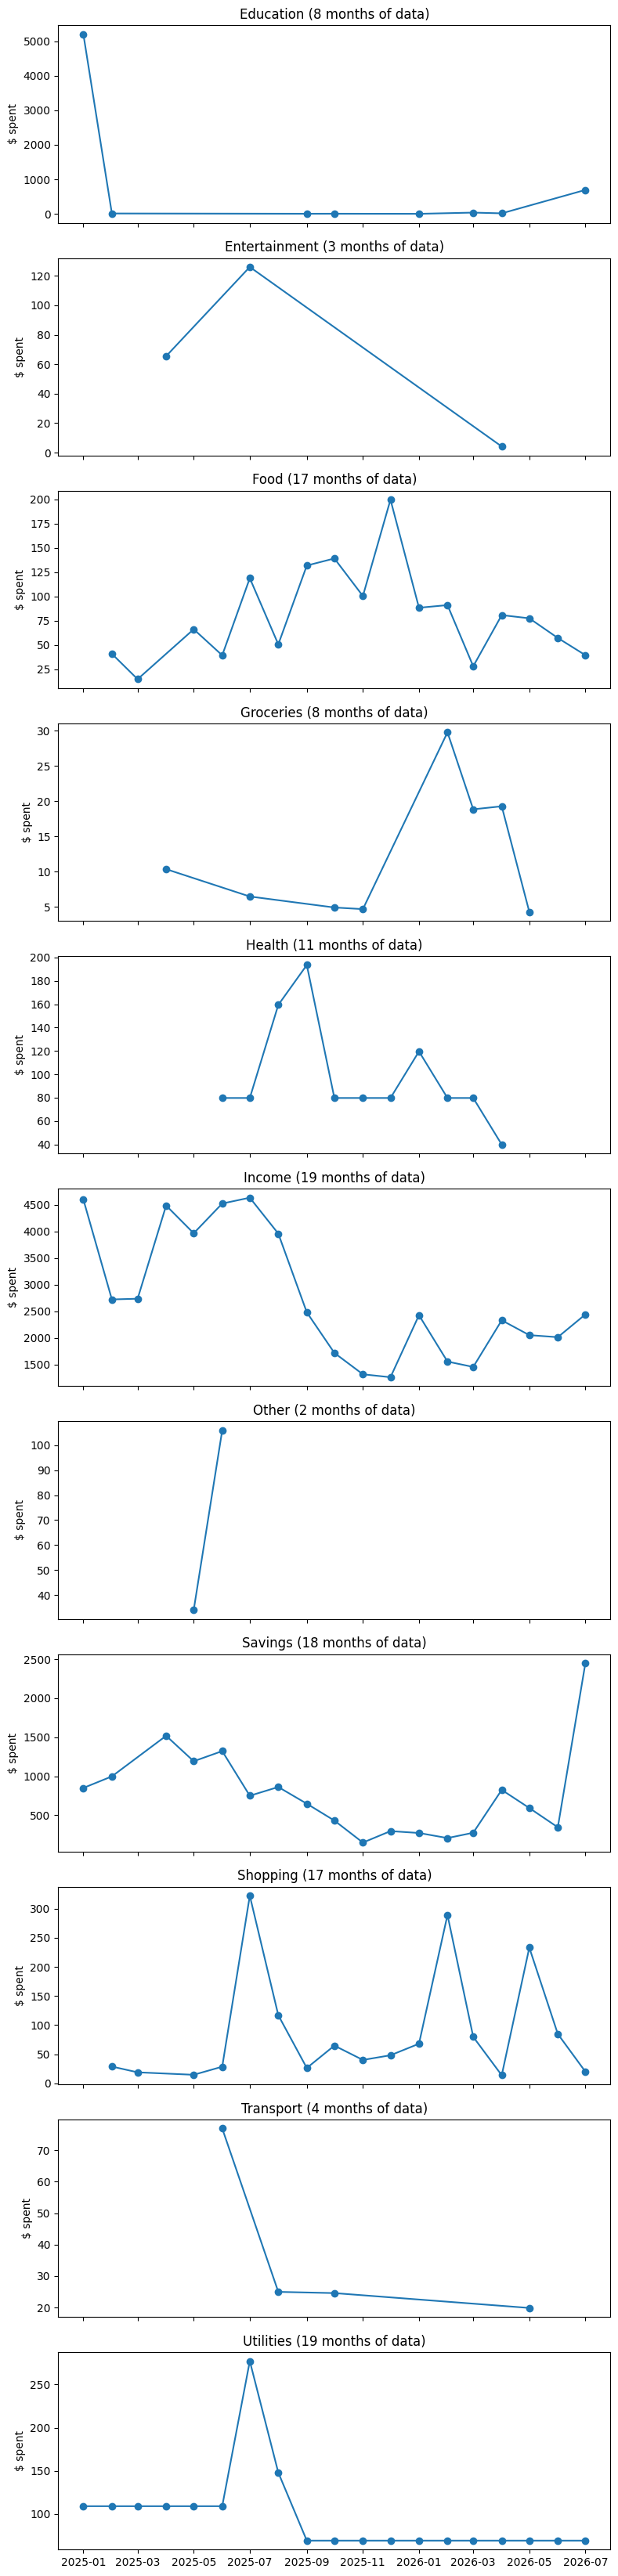

In [27]:
categories = monthly["category"].unique()
fig, axes = plt.subplots(len(categories), 1, figsize=(8, 3 * len(categories)), sharex=True)
if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    subset = monthly[monthly["category"] == cat]
    ax.plot(subset["month"], subset["abs_amount"], marker="o")
    ax.set_title(f"{cat} ({len(subset)} months of data)")
    ax.set_ylabel("$ spent")

plt.tight_layout()
plt.show()

## Quick Prophet test on one category

Pick whichever category above has the most months of data and try an actual Prophet fit, to see what its output/confidence intervals look like against real (not synthetic) data. Swap `TEST_CATEGORY` to whatever `coverage` showed has the best history.

In [28]:
from prophet import Prophet

TEST_CATEGORY = "Food"  # change based on what `coverage` shows

series = monthly[monthly["category"] == TEST_CATEGORY][["month", "abs_amount"]].rename(
    columns={"month": "ds", "abs_amount": "y"}
)
print(f"{len(series)} monthly data points for {TEST_CATEGORY}")
series

17 monthly data points for Food


,ds,y
11,2025-02-01,40.90
12,2025-03-01,14.76
13,2025-05-01,66.22
14,2025-06-01,39.36
15,2025-07-01,118.84
16,2025-08-01,50.62
17,2025-09-01,131.85
18,2025-10-01,139.16
19,2025-11-01,100.45
20,2025-12-01,199.74


08:50:20 - cmdstanpy - INFO - Chain [1] start processing
08:50:20 - cmdstanpy - INFO - Chain [1] done processing


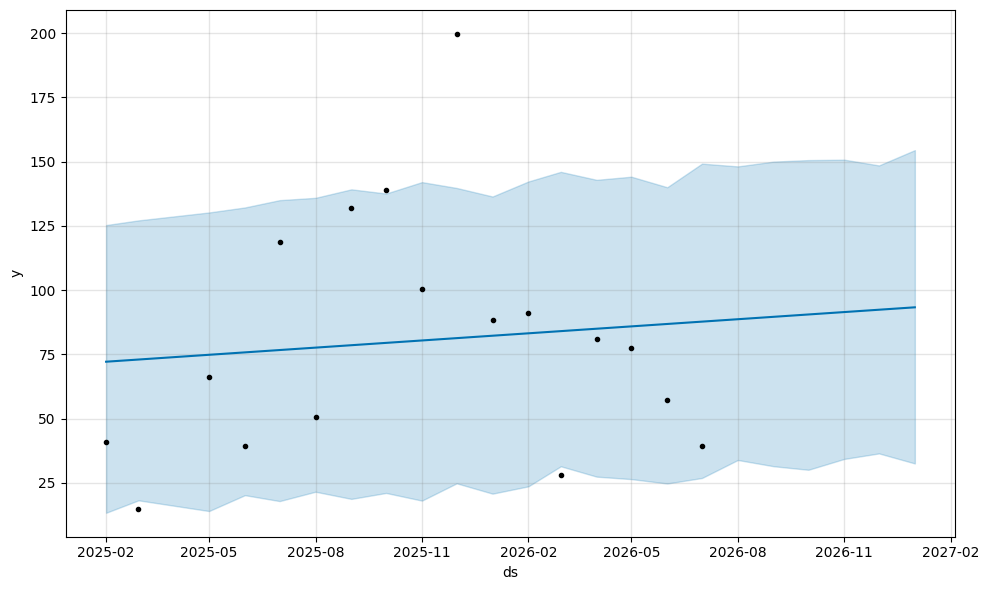

,ds,yhat,yhat_lower,yhat_upper
17,2026-08-01,88.661179,33.846390,148.168900
18,2026-09-01,89.600536,31.414050,150.032631
19,2026-10-01,90.509591,30.035235,150.622220
20,2026-11-01,91.448948,34.263655,150.782841
21,2026-12-01,92.358004,36.409301,148.542396
22,2027-01-01,93.297361,32.498015,154.506416


In [29]:
model = Prophet()
model.fit(series)

future = model.make_future_dataframe(periods=6, freq="MS")  # 3 months out — placeholder, revisit after seeing this
forecast = model.predict(future)

fig = model.plot(forecast)
plt.show()

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(6)

## Next steps

Once this runs against your real data:
1. Look at the `coverage` table — decide the real `insufficient_data` month-count threshold based on what categories actually clear the bar.
2. Look at the Prophet plot's confidence interval width — if it's absurdly wide with few data points, that's a signal for the minimum threshold too, separate from just "do we have 3 rows."
3. Confirm 3-month horizon still makes sense, or adjust based on how many data points you actually have to forecast from.
4. Bring findings back and we'll lock in `forecaster.py`'s constants.